# Système de recommandation agricole - Feature engineering
- L'objectif ici va d'être de réaliser l'enrichissement de notre nouveau df avec les varibales clés de crop_yield
- Ensuite on va passer au feature engineering à proprement parlé

In [2]:
# Imports de base
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

## On charge nos données

In [2]:
# Fichier yield consolidé
data_yield_conso = pd.read_csv("../data/processed/yield_df_final.csv")
crop_yield = pd.read_csv("../data/raw/crop_yield.csv")

### Vérification des cultures par fichier

In [3]:
# Type de culture unique par fichier
print(f"Type de culture dans yield :{data_yield_conso['item'].unique()}\n")
print(f"Type de culture dans crop_yield :{crop_yield['Crop'].unique()}\n")
print("="*20)
# Valeur par type de culture par fichier
print(f"Fichier yield consolidé : {data_yield_conso['item'].value_counts()}\n")
print(f"Fichier crop_yield : {crop_yield['Crop'].value_counts()}")

Type de culture dans yield :<StringArray>
[               'Maize',             'Potatoes',          'Rice, paddy',
                'Wheat',              'Sorghum',             'Soybeans',
              'Cassava',                 'Yams',       'Sweet potatoes',
 'Plantains and others']
Length: 10, dtype: str

Type de culture dans crop_yield :<StringArray>
['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize']
Length: 6, dtype: str

Fichier yield consolidé : item
Maize                   4426
Potatoes                4163
Wheat                   3289
Rice, paddy             3171
Sweet potatoes          3111
Sorghum                 2826
Cassava                 2771
Soybeans                2428
Yams                    1615
Plantains and others    1351
Name: count, dtype: int64

Fichier crop_yield : Crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64


On note une différence entre les fichiers sur les types de culture :

- Nous devons effectuer un mapping pour faire correspondre les bonnes cultures
- **On note également qu'il y a 10 cultures dans le fchier consolidé et seulement 6 dans le dataset synthétique. Il faudrait bien avoir ça en tête lors de l'imputation.**
- Les éléments suivants n'auront pas d'équivalents directs :
    - Potatoes
    - Sweet potatoes
    - Sorghum
    - Cassava
    - Yams
    - Plantains and others
- L'idée va être de réunir un maximum d'informations depuis la relation culture des deux datasets et pour les relations directes manquantes, nous allons le faire par pays dans le fichier consolidé puis par groupe climatique
- On voit également que la dataset "synthétique" propose un équilibre quasi parfait entre type de culture

### Aanalyse des variables similaires

In [4]:
print(f"Fichier yield consolidé : \n{data_yield_conso[["avg_temp","rainfall_mm"]].describe()}\n")
print(f"Fichier crop_yield : \n{crop_yield[["Temperature_Celsius","Rainfall_mm"]].describe()}\n")

Fichier yield consolidé : 
           avg_temp   rainfall_mm
count  29151.000000  29151.000000
mean      20.286183   1227.017289
std        5.911377    746.155030
min       -3.370000     51.000000
25%       17.330000    637.000000
50%       21.340000   1146.000000
75%       24.930000   1705.000000
max       30.420000   3240.000000

Fichier crop_yield : 
       Temperature_Celsius     Rainfall_mm
count       1000000.000000  1000000.000000
mean             27.504965      549.981901
std               7.220608      259.851320
min              15.000034      100.000896
25%              21.254502      324.891090
50%              27.507365      550.124061
75%              33.753267      774.738520
max              39.999997      999.998098



Les statistiques ne donnent pas les mêmes amplitudes par variables :
- Du côté du fichier consolidé sur la temp on a pas la distinction des pays avec climat froid, le minimum est à 15 degrés alors qu'il est à -3 pour le fichier consolidé, on note un écart pour le maximum également.
- Ce n'est pas parfait pour ajouter des données mais l'idée est de rajouter des proxys, donc des mesures approximatives afin d'aider un modèle à trouver des patterns.

### Normalisation des noms dans notre fichier consolidé

In [5]:
# Utilisation de replace pour changer les noms
data_yield_conso['item'] = data_yield_conso['item'].replace({
    'Rice, paddy': 'Rice',
    'Soybeans': 'Soybean',
    'Maize': 'Maize',
    'Wheat': 'Wheat',
    'Barley': 'Barley'
})
data_yield_conso['item'].unique()

<StringArray>
[               'Maize',             'Potatoes',                 'Rice',
                'Wheat',              'Sorghum',              'Soybean',
              'Cassava',                 'Yams',       'Sweet potatoes',
 'Plantains and others']
Length: 10, dtype: str

## Enrichissement du fichier consolidé

Il n'y a de relation directe entre notre premier dataset (celui pour l'ACP) et les autres datasets.
- Le premier fichier est par grande région et culture
- Le deuxième fichier est par pays, par année puis par culture
- Le rapprochement des données serait très bancal.

**Mais nous avons identifié des variables proxy qui pourraient enrichir notre dataset :**
- Irrigation_Used
- Fertilizer_Used
- Weather_Condition
- Soil_Type

Le fichier crop_yield semble être un fichier synthétique :
- Pas de corrélation entre les variables explicatives
- Répartition à quasi 50/50 des valeurs pour chaque variables 

Plusieurs méthodes d'enrichissement ont été effectué :
- Modèle de régression logistique afin de prédire les différentes variables sur le nouveau fichier
    - Variables explicative : précipitation et température
    - Après un test, le modèle n'arrive pas à généraliser, les variables explicatives sont indépendantes entre elles Les données sont "plates" (sans corrélations fortes), le modèle de ML essayait de trouver une règle là où il n'y en a pas
    - Par exemple, la balanced_accuracy était à 0,50 pour le fertilisant et l'irrigation

- Méthode de stratification par catégorie afin de faire le rapprochement sur le nouveau fichier en utilisation la valeur la plus fréquente (mode())
    - La mise en place de la stratification était simple (en quartiles)
    - Le problème est l'utilisation de la valeur fréquente. Quand il y a une valeur qui se démarque, cela fonctionne bien. Cependant sur une égalité, le mode choisit aléatoirement
- Méthode de sampling conditionnel afin d'attribuer la distribution de crop_yield par culture/clé climatique puis choix statistique de la valeur avec une fonction random
    - Méthode retenue

### Méthode du sampling conditionnel

- Standardisation des noms des types de culture entre les fichiers
- Autre problématique : nous avons uniquement 4 cultures en communs entre les 2 fichiers

In [6]:
# Avoir de pouvoir reproduire nos éléments
np.random.seed(42)
# Chargement de nos fichiers
yield_df_final = data_yield_conso
yield_df = yield_df_final.copy()
crop_df = crop_yield.copy()
# Colonnes que l'on veut retrouver
cols = ["Fertilizer_Used", "Irrigation_Used", "Weather_Condition", "Soil_Type"]
# Créer les colonnes manquantes en object, pas en float
for col in cols:
    if col not in yield_df.columns:
        yield_df[col] = pd.Series([None] * len(yield_df), dtype="object")
    else:
        yield_df[col] = yield_df[col].astype("object")

### Création de la clé climatique

In [7]:
# Construire climate_key avec les bornes apprises sur crop_yield
temp_edges = crop_df["Temperature_Celsius"].quantile([0.25, 0.5, 0.75]).tolist()
rain_edges = crop_df["Rainfall_mm"].quantile([0.25, 0.5, 0.75]).tolist()

temp_bins = [-np.inf] + temp_edges + [np.inf]
rain_bins = [-np.inf] + rain_edges + [np.inf]

labels_t = ["T1", "T2", "T3", "T4"]
labels_r = ["R1", "R2", "R3", "R4"]

crop_df["temp_q"] = pd.cut(
    crop_df["Temperature_Celsius"],
    bins=temp_bins,
    labels=labels_t,
    include_lowest=True
)
crop_df["rain_q"] = pd.cut(
    crop_df["Rainfall_mm"],
    bins=rain_bins,
    labels=labels_r,
    include_lowest=True
)
crop_df["climate_key"] = crop_df["temp_q"].astype(str) + "_" + crop_df["rain_q"].astype(str)

yield_df["temp_q"] = pd.cut(
    yield_df["avg_temp"],
    bins=temp_bins,
    labels=labels_t,
    include_lowest=True
)
yield_df["rain_q"] = pd.cut(
    yield_df["rainfall_mm"],
    bins=rain_bins,
    labels=labels_r,
    include_lowest=True
)
yield_df["climate_key"] = yield_df["temp_q"].astype(str) + "_" + yield_df["rain_q"].astype(str)


### Récupération de la distribution des éléments depuis crop_yield

In [8]:
# Distributions depuis crop_yield
dist_ref = {}
dist_crop = {}
dist_global = {}

for col in cols:
    dist_ref[col] = crop_df.groupby(["climate_key", "Crop"])[col].value_counts(normalize=True)
    dist_crop[col] = crop_df.groupby("Crop")[col].value_counts(normalize=True)
    dist_global[col] = crop_df[col].value_counts(normalize=True)

# Fonction de sampling
def sample_value(row, col):
    ck = row["climate_key"]
    crop = row["item"]

    # climate_key + crop
    try:
        dist = dist_ref[col].loc[(ck, crop)]
        return np.random.choice(dist.index.to_list(), p=dist.values)
    except Exception:
        pass

    # crop seul
    try:
        dist = dist_crop[col].loc[crop]
        return np.random.choice(dist.index.to_list(), p=dist.values)
    except Exception:
        pass

    # global
    dist = dist_global[col]
    return np.random.choice(dist.index.to_list(), p=dist.values)

### Imputation des NaN ligne par ligne

In [9]:
# Remplir les NaN ligne par ligne
for col in cols:
    mask = yield_df[col].isna()

    if mask.sum() > 0:
        sampled_values = yield_df.loc[mask].apply(
            lambda row: sample_value(row, col),
            axis=1
        )

        yield_df.loc[mask, col] = sampled_values.astype("object")

# Recast final propre
yield_df["Fertilizer_Used"] = yield_df["Fertilizer_Used"].astype(bool)
yield_df["Irrigation_Used"] = yield_df["Irrigation_Used"].astype(bool)
yield_df["Weather_Condition"] = yield_df["Weather_Condition"].astype(str)
yield_df["Soil_Type"] = yield_df["Soil_Type"].astype(str)

# 8) Vérification
print("NaN restants :")
print(yield_df[cols].isna().sum())

# 9) Nettoyage optionnel
yield_df = yield_df.drop(columns=["temp_q", "rain_q"], errors="ignore")

yield_df_final = yield_df.copy()

NaN restants :
Fertilizer_Used      0
Irrigation_Used      0
Weather_Condition    0
Soil_Type            0
dtype: int64


### Vérification des distributions

In [10]:
# Pour les variables proxy
cols = ['Fertilizer_Used','Irrigation_Used','Weather_Condition','Soil_Type']
for col in cols:
    print(f"\n=== {col} ===")
    print("Source (crop_yield):")
    print(crop_yield[col].value_counts(normalize=True))

    print("\nFinal (yield_df_final):")
    print(yield_df_final[col].value_counts(normalize=True))


=== Fertilizer_Used ===
Source (crop_yield):
Fertilizer_Used
False    0.50006
True     0.49994
Name: proportion, dtype: float64

Final (yield_df_final):
Fertilizer_Used
False    0.501252
True     0.498748
Name: proportion, dtype: float64

=== Irrigation_Used ===
Source (crop_yield):
Irrigation_Used
False    0.500509
True     0.499491
Name: proportion, dtype: float64

Final (yield_df_final):
Irrigation_Used
True     0.503482
False    0.496518
Name: proportion, dtype: float64

=== Weather_Condition ===
Source (crop_yield):
Weather_Condition
Sunny     0.333790
Rainy     0.333561
Cloudy    0.332649
Name: proportion, dtype: float64

Final (yield_df_final):
Weather_Condition
Cloudy    0.335666
Sunny     0.333436
Rainy     0.330898
Name: proportion, dtype: float64

=== Soil_Type ===
Source (crop_yield):
Soil_Type
Sandy     0.167119
Loam      0.166795
Chalky    0.166779
Silt      0.166672
Clay      0.166352
Peaty     0.166283
Name: proportion, dtype: float64

Final (yield_df_final):
Soil_Type

In [11]:
# Par type de crop et variable proxy
for col in cols:
    print(f"\n=== {col} par crop ===")
    
    source = crop_yield.groupby("Crop")[col].value_counts(normalize=True)
    final = yield_df_final.groupby("item")[col].value_counts(normalize=True)
    
    print(pd.concat([source.rename("source"), final.rename("final")], axis=1).head())


=== Fertilizer_Used par crop ===
                          source     final
       Fertilizer_Used                    
Barley False            0.500741       NaN
       True             0.499259       NaN
Cotton True             0.500609       NaN
       False            0.499391       NaN
Maize  False            0.501547  0.497063

=== Irrigation_Used par crop ===
                          source     final
       Irrigation_Used                    
Barley False            0.500495       NaN
       True             0.499505       NaN
Cotton False            0.500489       NaN
       True             0.499511       NaN
Maize  False            0.500042  0.493674

=== Weather_Condition par crop ===
                            source  final
       Weather_Condition                 
Barley Rainy              0.334872    NaN
       Sunny              0.332954    NaN
       Cloudy             0.332174    NaN
Cotton Sunny              0.335078    NaN
       Rainy              0.333878    NaN


### Séléction des bonnes colonnes

In [12]:
yield_df_final.columns

Index(['Unnamed: 0', 'area', 'year', 'item', 'avg_temp', 'rainfall_mm',
       'pesticides_tonnes', 'yield', 'Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition', 'Soil_Type', 'climate_key'],
      dtype='str')

In [13]:
cols = ['area', 'year', 'item', 'avg_temp', 'rainfall_mm',
       'pesticides_tonnes', 'Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition', 'Soil_Type', 'yield']
yield_df_enriched = yield_df_final[cols]

### Sauvegarde du nouveau fichier

In [14]:
yield_df_enriched.to_csv('../data/processed/yield_df_enriched.csv')

## Feature engineering sur le fichier enrichi

Nous avons désormais consolidé notre dataset :
- Une première fois avec 3 variables climatiques puis imputer de manière rigoureuse pour les données manquantes.
- Une deuxième fois en enrichissant le dataset avec des variables approximatives qui devraient aider notre modèle à mieux généraliser

Nous devons maintenant continuer l'amélioration de nos données en ajoutant des données si disponibles, en transformant nos données pour être compréhensibles pour un modèle.

### Nouvelles variables
- regroupement des pays : regroupement par grande catégorie pour garder une certaine cohérence
- tech_trend : capte la croissance historique des rendements liée aux innovations technologiques au fil des ans.
- irrigation_impact : mesure l'importance vitale de l'apport d'eau artificiel, particulièrement élevée lorsque les précipitations naturelles sont insuffisantes.
- pest_rain_ratio : évalue l'efficacité potentielle des traitements chimiques en tenant compte du risque de lessivage par les fortes pluies.
- climate_instability : identifie les régions à risque en mesurant la variabilité.
- relative_tech_intensity : indique si l'effort technologique d'une année spécifique est supérieur ou inférieur à la norme historique du pays concerné.

In [3]:
yield_df_enriched = pd.read_csv("../data/processed/yield_df_enriched.csv")

### Nombre de valeurs par variable

In [4]:
yield_df_enriched['item'].value_counts()

item
Maize                   4426
Potatoes                4163
Wheat                   3289
Rice                    3171
Sweet potatoes          3111
Sorghum                 2826
Cassava                 2771
Soybean                 2428
Yams                    1615
Plantains and others    1351
Name: count, dtype: int64

In [5]:
cols = ['Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition', 'Soil_Type']
for col in cols:
    print(yield_df_enriched[col].value_counts())
    print("="*10)

Fertilizer_Used
False    14612
True     14539
Name: count, dtype: int64
Irrigation_Used
True     14677
False    14474
Name: count, dtype: int64
Weather_Condition
Cloudy    9785
Sunny     9720
Rainy     9646
Name: count, dtype: int64
Soil_Type
Sandy     4964
Chalky    4902
Silt      4853
Clay      4831
Peaty     4825
Loam      4776
Name: count, dtype: int64


- On voit que pour les variables catégorielles ci-dessus on va pouvoir utiliser le one hot vu le nombre de valeur limité (colonne supplémentaire limité)

### Regroupement des pays
- On ne peut pas utiliser la méthode one hot pour les pays, il y en a trop.
- On décide alors de les regouper par grande catégorie pour garder une certaine cohérence

In [6]:
# On calcule les médianes pour les 3 features explicatives numériques
med_temp = yield_df_enriched['avg_temp'].median()
med_rain = yield_df_enriched['rainfall_mm'].median()
med_pest = yield_df_enriched['pesticides_tonnes'].median()

# On crée une fonction de classification simple
def classify_agro_profile(row):
    t = "hot" if row['avg_temp'] > med_temp else "cold"
    r = "wet" if row['rainfall_mm'] > med_rain else "dry"
    p = "intensive" if row['pesticides_tonnes'] > med_pest else "extensive"
    
    return f"{t}_{r}_{p}"

# On applique la stratification
yield_df_enriched['Agro_Profile'] = yield_df_enriched.apply(classify_agro_profile, axis=1)

# On vérifie le nombre de lignes par groupe
print(yield_df_enriched['Agro_Profile'].value_counts())

Agro_Profile
cold_dry_intensive    6460
cold_dry_extensive    6005
hot_wet_extensive     4509
cold_wet_extensive    4222
hot_wet_intensive     2727
hot_dry_extensive     2343
cold_wet_intensive    1989
hot_dry_intensive      896
Name: count, dtype: int64


### Ajout des nouvelles variables

In [7]:
# Progrès technique
yield_df_enriched['tech_trend'] = yield_df_enriched['year'] - yield_df_enriched['year'].min()
# Ratio climatique - indice d'irrigation critique
yield_df_enriched['irrigation_impact'] = yield_df_enriched['Irrigation_Used'].astype(int) / (yield_df_enriched['rainfall_mm'] + 1)
# Écart-type de la température par pays (mesure de l'instabilité)
yield_df_enriched['climate_instability'] = yield_df_enriched.groupby('area')['avg_temp'].transform('std')
# Le relative tech-age
avg_pest_country = yield_df_enriched.groupby('area')['pesticides_tonnes'].transform('mean')
yield_df_enriched['relative_tech_intensity'] = yield_df_enriched['pesticides_tonnes'] / (avg_pest_country + 1)

In [8]:
cols = ['area', 'item', 'avg_temp', 'rainfall_mm', 'pesticides_tonnes',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Soil_Type',
       'yield', 'Agro_Profile', 'tech_trend', 'irrigation_impact',
       'climate_instability','relative_tech_intensity']
yield_df_enriched = yield_df_enriched[cols]

In [9]:
yield_df_enriched.info()

<class 'pandas.DataFrame'>
RangeIndex: 29151 entries, 0 to 29150
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     29151 non-null  str    
 1   item                     29151 non-null  str    
 2   avg_temp                 29151 non-null  float64
 3   rainfall_mm              29151 non-null  float64
 4   pesticides_tonnes        29151 non-null  float64
 5   Fertilizer_Used          29151 non-null  bool   
 6   Irrigation_Used          29151 non-null  bool   
 7   Weather_Condition        29151 non-null  str    
 8   Soil_Type                29151 non-null  str    
 9   yield                    29151 non-null  int64  
 10  Agro_Profile             29151 non-null  str    
 11  tech_trend               29151 non-null  int64  
 12  irrigation_impact        29151 non-null  float64
 13  climate_instability      29151 non-null  float64
 14  relative_tech_intensity  29151 no

In [10]:
cols_num = [ 'avg_temp', 'rainfall_mm', 'pesticides_tonnes',
            'yield', 'tech_trend', 'irrigation_impact',
            'climate_instability','relative_tech_intensity']
spearman_corr = yield_df_enriched[cols_num].corr(numeric_only=True, method='spearman')
spearman_corr

,avg_temp,rainfall_mm,pesticides_tonnes,yield,tech_trend,irrigation_impact,climate_instability,relative_tech_intensity
avg_temp,1.000000,0.369051,-0.328893,-0.077806,0.002120,-0.105944,-0.418587,-0.031119
rainfall_mm,0.369051,1.000000,-0.016414,0.038608,-0.013579,-0.270273,-0.454108,-0.008145
pesticides_tonnes,-0.328893,-0.016414,1.000000,0.156642,0.045174,0.008786,0.339193,0.296878
yield,-0.077806,0.038608,0.156642,1.000000,0.075102,-0.018039,0.016343,0.054436
tech_trend,0.002120,-0.013579,0.045174,0.075102,1.000000,0.006695,0.019142,0.233816
irrigation_impact,-0.105944,-0.270273,0.008786,-0.018039,0.006695,1.000000,0.121214,0.004596
climate_instability,-0.418587,-0.454108,0.339193,0.016343,0.019142,0.121214,1.000000,0.039482
relative_tech_intensity,-0.031119,-0.008145,0.296878,0.054436,0.233816,0.004596,0.039482,1.000000


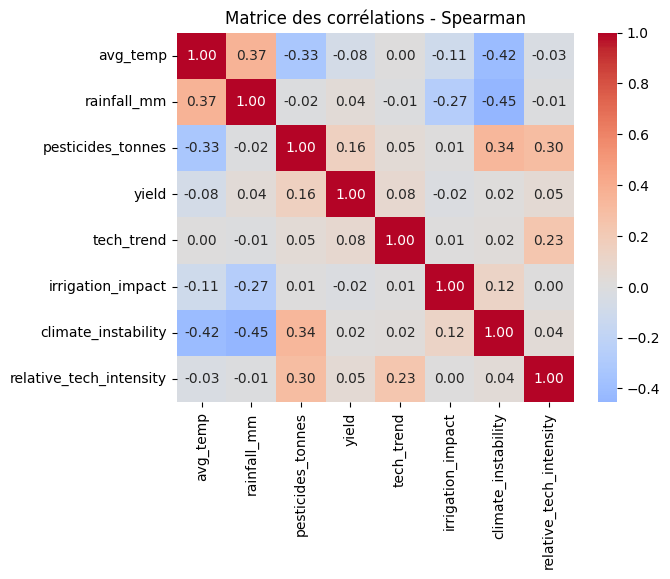

In [13]:
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Matrice des corrélations - Spearman')
plt.savefig('../notebooks/graph/matrice_correlation_spearman_conso.png')
plt.show()

## Encodage des variables catégorielles

Un modèle de machine learning ne peut pas comprendre les valeurs non numériques alors nous devons transformer nos variables catégorielles, quitte à avoir des colonnes supplémentaires.

- Utilisation de la méthode One Hot pour l'ensemble des variables catégorielles

In [14]:
yield_df_enriched

,area,item,avg_temp,rainfall_mm,pesticides_tonnes,Fertilizer_Used,Irrigation_Used,Weather_Condition,Soil_Type,yield,Agro_Profile,tech_trend,irrigation_impact,climate_instability,relative_tech_intensity
0,Afghanistan,Maize,15.450,327.0,1594.50,True,True,Rainy,Peaty,17582,cold_dry_extensive,0,0.003049,0.492884,0.999373
1,Afghanistan,Maize,14.570,327.0,1594.50,False,True,Cloudy,Sandy,16800,cold_dry_extensive,1,0.003049,0.492884,0.999373
2,Afghanistan,Maize,14.350,327.0,1594.50,False,False,Sunny,Sandy,15000,cold_dry_extensive,2,0.000000,0.492884,0.999373
3,Afghanistan,Maize,14.960,327.0,1594.50,False,True,Rainy,Peaty,16786,cold_dry_extensive,3,0.003049,0.492884,0.999373
4,Afghanistan,Maize,14.940,327.0,1594.50,True,True,Sunny,Clay,16667,cold_dry_extensive,4,0.003049,0.492884,0.999373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29146,Zimbabwe,Wheat,20.520,657.0,3375.53,True,False,Rainy,Loam,24420,cold_dry_intensive,22,0.000000,0.429556,1.096304
29147,Zimbabwe,Wheat,19.760,657.0,2550.07,False,True,Cloudy,Loam,22888,cold_dry_intensive,23,0.001520,0.429556,0.828211
29148,Zimbabwe,Wheat,20.765,657.0,2185.07,False,True,Cloudy,Peaty,21357,cold_dry_intensive,24,0.001520,0.429556,0.709667
29149,Zimbabwe,Wheat,20.765,657.0,2185.07,False,True,Cloudy,Loam,19826,cold_dry_intensive,25,0.001520,0.429556,0.709667


In [15]:
yield_df_enriched.info()

<class 'pandas.DataFrame'>
RangeIndex: 29151 entries, 0 to 29150
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     29151 non-null  str    
 1   item                     29151 non-null  str    
 2   avg_temp                 29151 non-null  float64
 3   rainfall_mm              29151 non-null  float64
 4   pesticides_tonnes        29151 non-null  float64
 5   Fertilizer_Used          29151 non-null  bool   
 6   Irrigation_Used          29151 non-null  bool   
 7   Weather_Condition        29151 non-null  str    
 8   Soil_Type                29151 non-null  str    
 9   yield                    29151 non-null  int64  
 10  Agro_Profile             29151 non-null  str    
 11  tech_trend               29151 non-null  int64  
 12  irrigation_impact        29151 non-null  float64
 13  climate_instability      29151 non-null  float64
 14  relative_tech_intensity  29151 no

### Avant traitement

In [17]:
yield_df_enriched_old = yield_df_enriched
print(f"Nombre de lignes et de colonnes {yield_df_enriched_old.shape}")

Nombre de lignes et de colonnes (29151, 15)


### Encodage One Hot

In [36]:
# Transformer des colonnes en True/False
yield_df_enriched['Irrigation_Used'] = yield_df_enriched['Irrigation_Used'].astype(int)
yield_df_enriched['Fertilizer_Used'] = yield_df_enriched['Fertilizer_Used'].astype(int)
# Séléction des colonnes numériques
num_cols = yield_df_enriched.select_dtypes(include='number').columns
num_cols = ['avg_temp', 'rainfall_mm',
       'Irrigation_Used', 'yield', 'tech_trend', 'irrigation_impact',
       'climate_instability', 'relative_tech_intensity']
cat_cols = yield_df_enriched.select_dtypes(include='str').columns
cat_cols = ['item', 'Weather_Condition', 'Soil_Type', 'Agro_Profile','Fertilizer_Used','Irrigation_Used']

In [44]:
yield_df_enriched = pd.get_dummies(yield_df_enriched, columns=cat_cols, dtype=float)

In [45]:
print(f"Nombre de lignes et de colonnes {yield_df_enriched_old.shape}")
print(f"Nombre de lignes et de colonnes {yield_df_enriched.shape}")

Nombre de lignes et de colonnes (29151, 15)
Nombre de lignes et de colonnes (29151, 40)
